# LABORATORIO 03: Predicción de Precios de Viviendas
**Estudiante:** Kevin Ayrton Diaz  
**Dataset:** House Sales in King County, USA

A partir de los cuadernillos revisados en clase, se eligió este dataset que contiene el registro de ventas de casas en King County. Cuenta con **21,613 ejemplos** (cumpliendo $m \ge 2000$) y **21 columnas**. Nuestra variable objetivo ($y$) será el precio (`price`), y utilizaremos 18 características numéricas ($X$), cumpliendo con $n \ge 10$.

## 1. Carga de Datos y Preprocesamiento
Quitaremos las columnas `id` y `date` porque no aportan valor matemático al modelo de regresión. Luego, separaremos el 80% para entrenamiento y 20% para pruebas, aplicando la normalización Z-score para el Descenso por el Gradiente.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('/content/kc_house_data.csv')

# Vemos el tamaño para confirmar que cumple los requisitos
print(f"Número de filas (m): {df.shape[0]}")
print(f"Número de columnas original: {df.shape[1]}")

# Eliminamos columnas que no aportan a la regresión (id y fecha)
df = df.drop(['id', 'date'], axis=1)

df = df.dropna()  # Borra cualquier fila con datos en blanco

# Definimos la etiqueta y (precio) y las características X
y = df['price'].values
X_df = df.drop(['price'], axis=1)
X_raw = X_df.values

print(f"Características seleccionadas (n): {X_raw.shape[1]}")

# Partición 80/20 manual
m = len(y)
train_size = int(0.8 * m)

# Mezclamos los datos para evitar sesgos
np.random.seed(42) # Semilla para reproducibilidad
indices = np.arange(m)
np.random.shuffle(indices)

X_shuffled = X_raw[indices]
y_shuffled = y[indices]

X_train = X_shuffled[:train_size]
y_train = y_shuffled[:train_size]
X_test = X_shuffled[train_size:]
y_test = y_shuffled[train_size:]

# Normalización Z-score (solo con datos de entrenamiento para evitar fuga de información)
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
sigma[sigma == 0] = 1 # Por si hay alguna columna constante

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

# Agregamos la columna de unos (X0) para el término independiente
X_train_final = np.concatenate([np.ones((len(X_train_norm), 1)), X_train_norm], axis=1)
X_test_final = np.concatenate([np.ones((len(X_test_norm), 1)), X_test_norm], axis=1)

print("Datos listos y normalizados.")

Número de filas (m): 21613
Número de columnas original: 21
Características seleccionadas (n): 18
Datos listos y normalizados.


## 2. Funciones Matemáticas de Regresión
Definimos la Función de Costo (Error Cuadrático Medio) y el algoritmo de Descenso por el Gradiente que usaremos tanto para el modelo Lineal como para el Polinómico.

In [9]:
def calcularCosto(X, y, theta):
    m = len(y)
    predicciones = np.dot(X, theta)
    costo = (1 / (2 * m)) * np.sum(np.square(predicciones - y))
    return costo

def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros(num_iters)
    theta = theta.copy()

    for i in range(num_iters):
        error = np.dot(X, theta) - y
        # Vectorización del descenso del gradiente
        theta = theta - (alpha / m) * np.dot(X.T, error)
        J_history[i] = calcularCosto(X, y, theta)

    return theta, J_history

## 3. Entrenamiento: Regresión Lineal Multivariable
Se inicializa theta con ceros y aplicamos el Descenso por el Gradiente iterativamente. Finalmente, se plotea el historial del costo $J$ para verificar la correcta convergencia del modelo.

Entrenando Regresión Lineal...


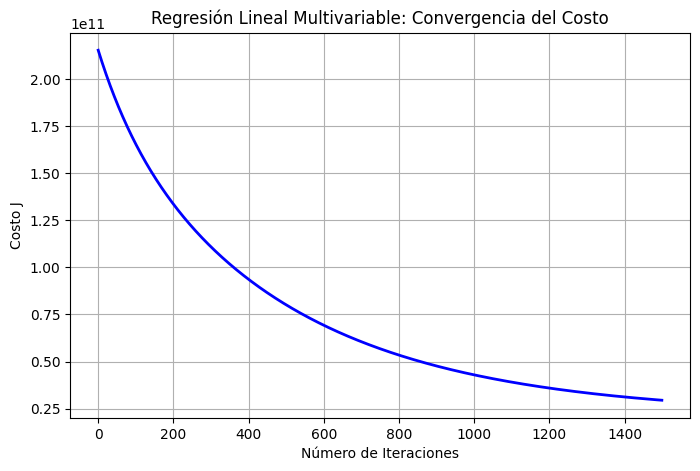

Costo final: 29513083150.82


In [10]:
alpha = 0.001
iteraciones = 1500
theta_inicial = np.zeros(X_train_final.shape[1])

print("Entrenando Regresión Lineal...")
theta_lineal, J_history_lineal = descensoGradiente(X_train_final, y_train, theta_inicial, alpha, iteraciones)

# Gráfico de costo
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history_lineal)), J_history_lineal, color='blue', lw=2)
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J')
plt.title('Regresión Lineal Multivariable: Convergencia del Costo')
plt.grid(True)
plt.show()

print(f"Costo final: {J_history_lineal[-1]:.2f}")

## 4. Entrenamiento: Regresión Polinómica
Para lograr que el modelo se adapte a relaciones no lineales, elevamos al cuadrado las características normalizadas, creando nuevas columnas, y volvemos a entrenar.

Entrenando Regresión Polinómica...


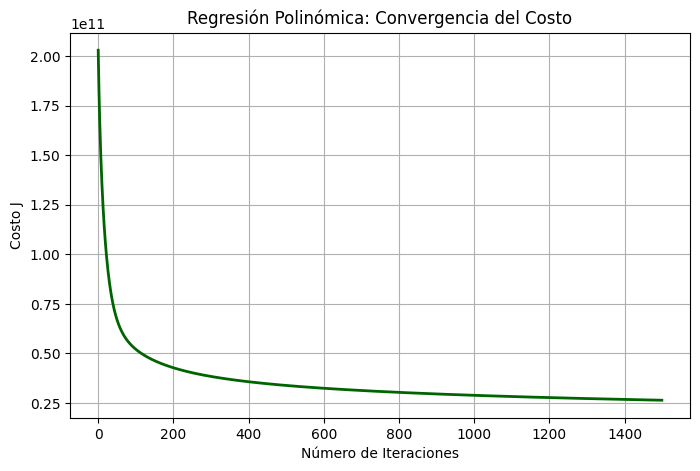

Costo final: 26420033377.44


In [11]:
# Elevamos al cuadrado las características para la regresión polinómica (Grado 2)
X_train_poly = np.concatenate([X_train_final, np.square(X_train_norm)], axis=1)
X_test_poly = np.concatenate([X_test_final, np.square(X_test_norm)], axis=1)

theta_inicial_poly = np.zeros(X_train_poly.shape[1])

print("Entrenando Regresión Polinómica...")
theta_poly, J_history_poly = descensoGradiente(X_train_poly, y_train, theta_inicial_poly, alpha, iteraciones)

# Gráfico de costo
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(J_history_poly)), J_history_poly, color='darkgreen', lw=2)
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J')
plt.title('Regresión Polinómica: Convergencia del Costo')
plt.grid(True)
plt.show()

print(f"Costo final: {J_history_poly[-1]:.2f}")

## 5. Entrenamiento: Ecuación de la Normal
Calculamos los parámetros analíticamente usando operaciones matriciales. A diferencia del descenso por el gradiente, este método **no requiere escalar los datos** ni iteraciones, por lo que le pasamos los datos en bruto con su columna de unos agregada.

In [12]:
# Usamos los datos originales (sin normalizar Z-score) y agregamos la columna de unos
X_train_eq = np.concatenate([np.ones((len(X_train), 1)), X_train], axis=1)
X_test_eq = np.concatenate([np.ones((len(X_test), 1)), X_test], axis=1)

def ecuacionNormal(X, y):
    # Fórmula analítica: theta = (X^T * X)^-1 * X^T * y
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

print("Calculando Ecuación de la Normal...")
theta_normal = ecuacionNormal(X_train_eq, y_train)
print("¡Parámetros óptimos calculados correctamente!")

Calculando Ecuación de la Normal...
¡Parámetros óptimos calculados correctamente!


## 6. Validación y Efectividad del Modelo
Utilizamos el 20% de los datos reservados (4,323 ejemplos, cumpliendo la exigencia de por lo menos 100 predicciones) para validar nuestros tres modelos. Mostraremos una comparativa de precios reales versus los predichos, y calcularemos el Error Cuadrático Medio Raíz (RMSE) para medir la efectividad.

In [13]:
# Realizamos las predicciones sobre todo el set de prueba (4323 predicciones simultáneas)
pred_lineal = np.dot(X_test_final, theta_lineal)
pred_poly = np.dot(X_test_poly, theta_poly)
pred_normal = np.dot(X_test_eq, theta_normal)

# Mostramos una tabla con 15 ejemplos para ver el comportamiento
df_resultados = pd.DataFrame({
    'Precio Real ($)': y_test[:15],
    'Predicción Lineal': pred_lineal[:15],
    'Predicción Polinómica': pred_poly[:15],
    'Predicción Normal': pred_normal[:15]
}).astype(int)

print("--- PREDICCIONES VS VALOR REAL (Primeros 15 casos de validación) ---")
print(df_resultados.to_string(index=False))

# Calculamos el RMSE para demostrar la efectividad global
print("\n--- EFECTIVIDAD GLOBAL DEL MODELO (Error RMSE) ---")
print("Nota: Un RMSE más bajo indica que el modelo comete menor margen de error en dólares.")
rmse_lineal = np.sqrt(np.mean(np.square(pred_lineal - y_test)))
rmse_poly = np.sqrt(np.mean(np.square(pred_poly - y_test)))
rmse_normal = np.sqrt(np.mean(np.square(pred_normal - y_test)))

print(f"Margen de Error - Regresión Lineal: ${rmse_lineal:,.2f}")
print(f"Margen de Error - Regresión Polinómica: ${rmse_poly:,.2f}")
print(f"Margen de Error - Ecuación Normal: ${rmse_normal:,.2f}")

--- PREDICCIONES VS VALOR REAL (Primeros 15 casos de validación) ---
 Precio Real ($)  Predicción Lineal  Predicción Polinómica  Predicción Normal
          527000             592069                 540656             710318
          445000             360318                 405830             409512
          435000             261670                 549528             325041
          970000            1014687                1122602            1177518
          345000             351845                 627670             464046
          166950               4450                 115408             120483
          770000             785353                 662695             948975
          910000             646469                 793711             791168
          340000             -48635                 487568             -22672
          308000             378750                 301783             429277
          340000             277215                 483516             42